In [1]:
import pandas as pd

df = pd.read_csv("3) Sentiment dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (732, 15)

Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

First 5 Rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
print("Text column missing values:", df["Text"].isnull().sum())
print("Sentiment column missing values:", df["Sentiment"].isnull().sum())

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

Text column missing values: 0
Sentiment column missing values: 0

Sentiment Distribution:
Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64


In [3]:
print("Total unique sentiments:", df["Sentiment"].nunique())

print("\nAll sentiment labels:")
print(sorted(df["Sentiment"].unique()))

Total unique sentiments: 279

All sentiment labels:
[' Acceptance   ', ' Acceptance      ', ' Accomplishment ', ' Admiration ', ' Admiration   ', ' Admiration    ', ' Adoration    ', ' Adrenaline     ', ' Adventure ', ' Affection    ', ' Amazement ', ' Ambivalence ', ' Ambivalence     ', ' Amusement    ', ' Amusement     ', ' Anger        ', ' Anticipation ', ' Anticipation  ', ' Anxiety   ', ' Anxiety         ', ' Appreciation  ', ' Apprehensive ', ' Arousal       ', ' ArtisticBurst ', ' Awe ', ' Awe    ', ' Awe          ', ' Awe           ', ' Bad ', ' Betrayal ', ' Betrayal      ', ' Bitter       ', ' Bitterness ', ' Bittersweet ', ' Blessed       ', ' Boredom ', ' Boredom         ', ' Breakthrough ', ' Calmness     ', ' Calmness      ', ' Captivation ', ' Celebration ', ' Celestial Wonder ', ' Challenge ', ' Charm ', ' Colorful ', ' Compassion', ' Compassion    ', ' Compassionate ', ' Confidence    ', ' Confident ', ' Confusion ', ' Confusion    ', ' Confusion       ', ' Connection

In [4]:
# Remove extra spaces from sentiment labels
df["Sentiment"] = df["Sentiment"].str.strip()

print("Unique sentiments after cleaning:", df["Sentiment"].nunique())

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

Unique sentiments after cleaning: 191

Sentiment Distribution:
Sentiment
Positive                45
Joy                     44
Excitement              37
Contentment             19
Neutral                 18
                        ..
Creative Inspiration     1
Runway Creativity        1
Ocean's Freedom          1
Whispers of the Past     1
Relief                   1
Name: count, Length: 191, dtype: int64


In [5]:
print("Top 20 Sentiment Classes:")
print(df["Sentiment"].value_counts().head(20))

Top 20 Sentiment Classes:
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Nostalgia      11
Awe             9
Grief           9
Loneliness      9
Hopeful         9
Sad             9
Acceptance      8
Confusion       8
Embarrassed     8
Pride           7
Name: count, dtype: int64


In [6]:
# Check how many classes have different numbers of samples

print("Classes with at least 5 samples:",
      (df["Sentiment"].value_counts() >= 5).sum())

print("Classes with at least 3 samples:",
      (df["Sentiment"].value_counts() >= 3).sum())

print("Classes with only 1 sample:",
      (df["Sentiment"].value_counts() == 1).sum())

Classes with at least 5 samples: 43
Classes with at least 3 samples: 83
Classes with only 1 sample: 79


In [7]:
# Keep sentiment classes having at least 5 samples

sentiment_counts = df["Sentiment"].value_counts()

df_nlp = df[df["Sentiment"].isin(
    sentiment_counts[sentiment_counts >= 5].index
)].copy()

print("Original dataset:", df.shape)
print("Filtered dataset:", df_nlp.shape)
print("Number of sentiment classes:", df_nlp["Sentiment"].nunique())

print("\nSentiment distribution:")
print(df_nlp["Sentiment"].value_counts())

Original dataset: (732, 15)
Filtered dataset: (458, 15)
Number of sentiment classes: 43

Sentiment distribution:
Sentiment
Positive         45
Joy              44
Excitement       37
Contentment      19
Neutral          18
Gratitude        18
Curiosity        16
Serenity         15
Happy            14
Despair          11
Nostalgia        11
Awe               9
Grief             9
Loneliness        9
Hopeful           9
Sad               9
Acceptance        8
Confusion         8
Embarrassed       8
Pride             7
Elation           7
Euphoria          7
Enthusiasm        7
Determination     7
Surprise          6
Frustration       6
Regret            6
Indifference      6
Numbness          6
Melancholy        6
Ambivalence       6
Playful           6
Inspiration       6
Hate              6
Bad               6
Disgust           5
Happiness         5
Hope              5
Empowerment       5
Inspired          5
Bitterness        5
Frustrated        5
Betrayal          5
Name: count, dtyp

In [8]:
print("Original dataset:", df.shape)
print("Filtered dataset:", df_nlp.shape)
print("Number of sentiment classes:", df_nlp["Sentiment"].nunique())

Original dataset: (732, 15)
Filtered dataset: (458, 15)
Number of sentiment classes: 43


In [9]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text preprocessing function
def preprocess_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Keep alphabetic words and remove stopwords
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    
    return ' '.join(tokens)

# Apply preprocessing
df_nlp["Clean_Text"] = df_nlp["Text"].apply(preprocess_text)

# Display original and cleaned text
display(df_nlp[["Text", "Clean_Text", "Sentiment"]].head(10))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Text,Clean_Text,Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,Positive
2,Just finished an amazing workout! 💪 ...,finished amazing workout,Positive
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,Positive
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,Neutral
5,Feeling grateful for the little things in lif...,feeling grateful little thing life,Positive
6,Rainy days call for cozy blankets and hot coc...,rainy day call cozy blanket hot cocoa,Positive
7,The new movie release is a must-watch! ...,new movie release,Positive
9,Missing summer vibes and beach days. ...,missing summer vibe beach day,Neutral
10,Just published a new blog post. Check it out!...,published new blog post check,Positive
12,Exploring the city's hidden gems. ...,exploring city hidden gem,Positive


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert cleaned text into numerical features
X = tfidf.fit_transform(df_nlp["Clean_Text"])

# Target variable
y = df_nlp["Sentiment"]

print("TF-IDF Matrix Shape:", X.shape)
print("Number of Target Labels:", y.nunique())

TF-IDF Matrix Shape: (458, 4490)
Number of Target Labels: 43


In [11]:
from sklearn.model_selection import train_test_split

# Input text and target
X_text = df_nlp["Clean_Text"]
y = df_nlp["Sentiment"]

# Split into training and testing data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))
print("Training classes:", y_train.nunique())
print("Testing classes:", y_test.nunique())

Training samples: 366
Testing samples: 92
Training classes: 43
Testing classes: 43


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit only on training data
X_train = tfidf.fit_transform(X_train_text)

# Transform testing data using the same TF-IDF vocabulary
X_test = tfidf.transform(X_test_text)

print("Training TF-IDF Shape:", X_train.shape)
print("Testing TF-IDF Shape:", X_test.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

Training TF-IDF Shape: (366, 3732)
Testing TF-IDF Shape: (92, 3732)
Number of Features: 3732


In [13]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on test data
y_pred = logistic_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.25
Precision: 0.2672
Recall   : 0.25
F1-Score : 0.1832


In [15]:
from sklearn.metrics import classification_report

print("Detailed Classification Report")
print("=" * 70)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Detailed Classification Report
               precision    recall  f1-score   support

   Acceptance       1.00      0.50      0.67         2
  Ambivalence       0.00      0.00      0.00         1
          Awe       0.00      0.00      0.00         2
          Bad       0.00      0.00      0.00         1
     Betrayal       0.00      0.00      0.00         1
   Bitterness       0.00      0.00      0.00         1
    Confusion       0.00      0.00      0.00         2
  Contentment       1.00      0.25      0.40         4
    Curiosity       1.00      0.33      0.50         3
      Despair       0.00      0.00      0.00         2
Determination       0.00      0.00      0.00         1
      Disgust       0.00      0.00      0.00         1
      Elation       0.00      0.00      0.00         2
  Embarrassed       0.00      0.00      0.00         2
  Empowerment       0.00      0.00      0.00         1
   Enthusiasm       0.00      0.00      0.00         1
     Euphoria       0.00      0.0

In [16]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Calculate metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(
    y_test, y_pred_nb, average="weighted", zero_division=0
)
recall_nb = recall_score(
    y_test, y_pred_nb, average="weighted", zero_division=0
)
f1_nb = f1_score(
    y_test, y_pred_nb, average="weighted", zero_division=0
)

print("Naive Bayes Performance")
print("-----------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-Score :", round(f1_nb, 4))

Naive Bayes Performance
-----------------------
Accuracy : 0.1848
Precision: 0.1611
Recall   : 0.1848
F1-Score : 0.1031


In [18]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy, accuracy_nb],
    "Precision": [precision, precision_nb],
    "Recall": [recall, recall_nb],
    "F1-Score": [f1, f1_nb]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.2500,0.2672,0.2500,0.1832
1,Naive Bayes,0.1848,0.1611,0.1848,0.1031


<Figure size 1400x1200 with 0 Axes>

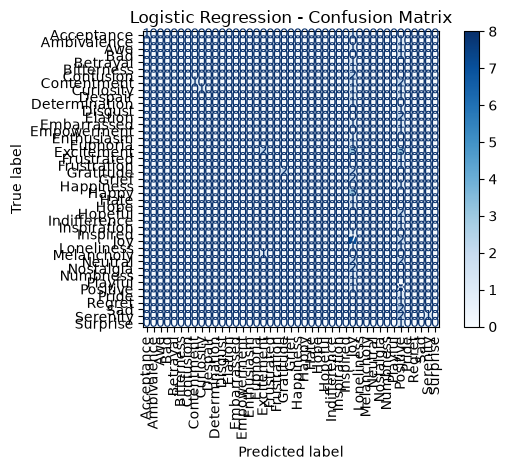

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot confusion matrix
plt.figure(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

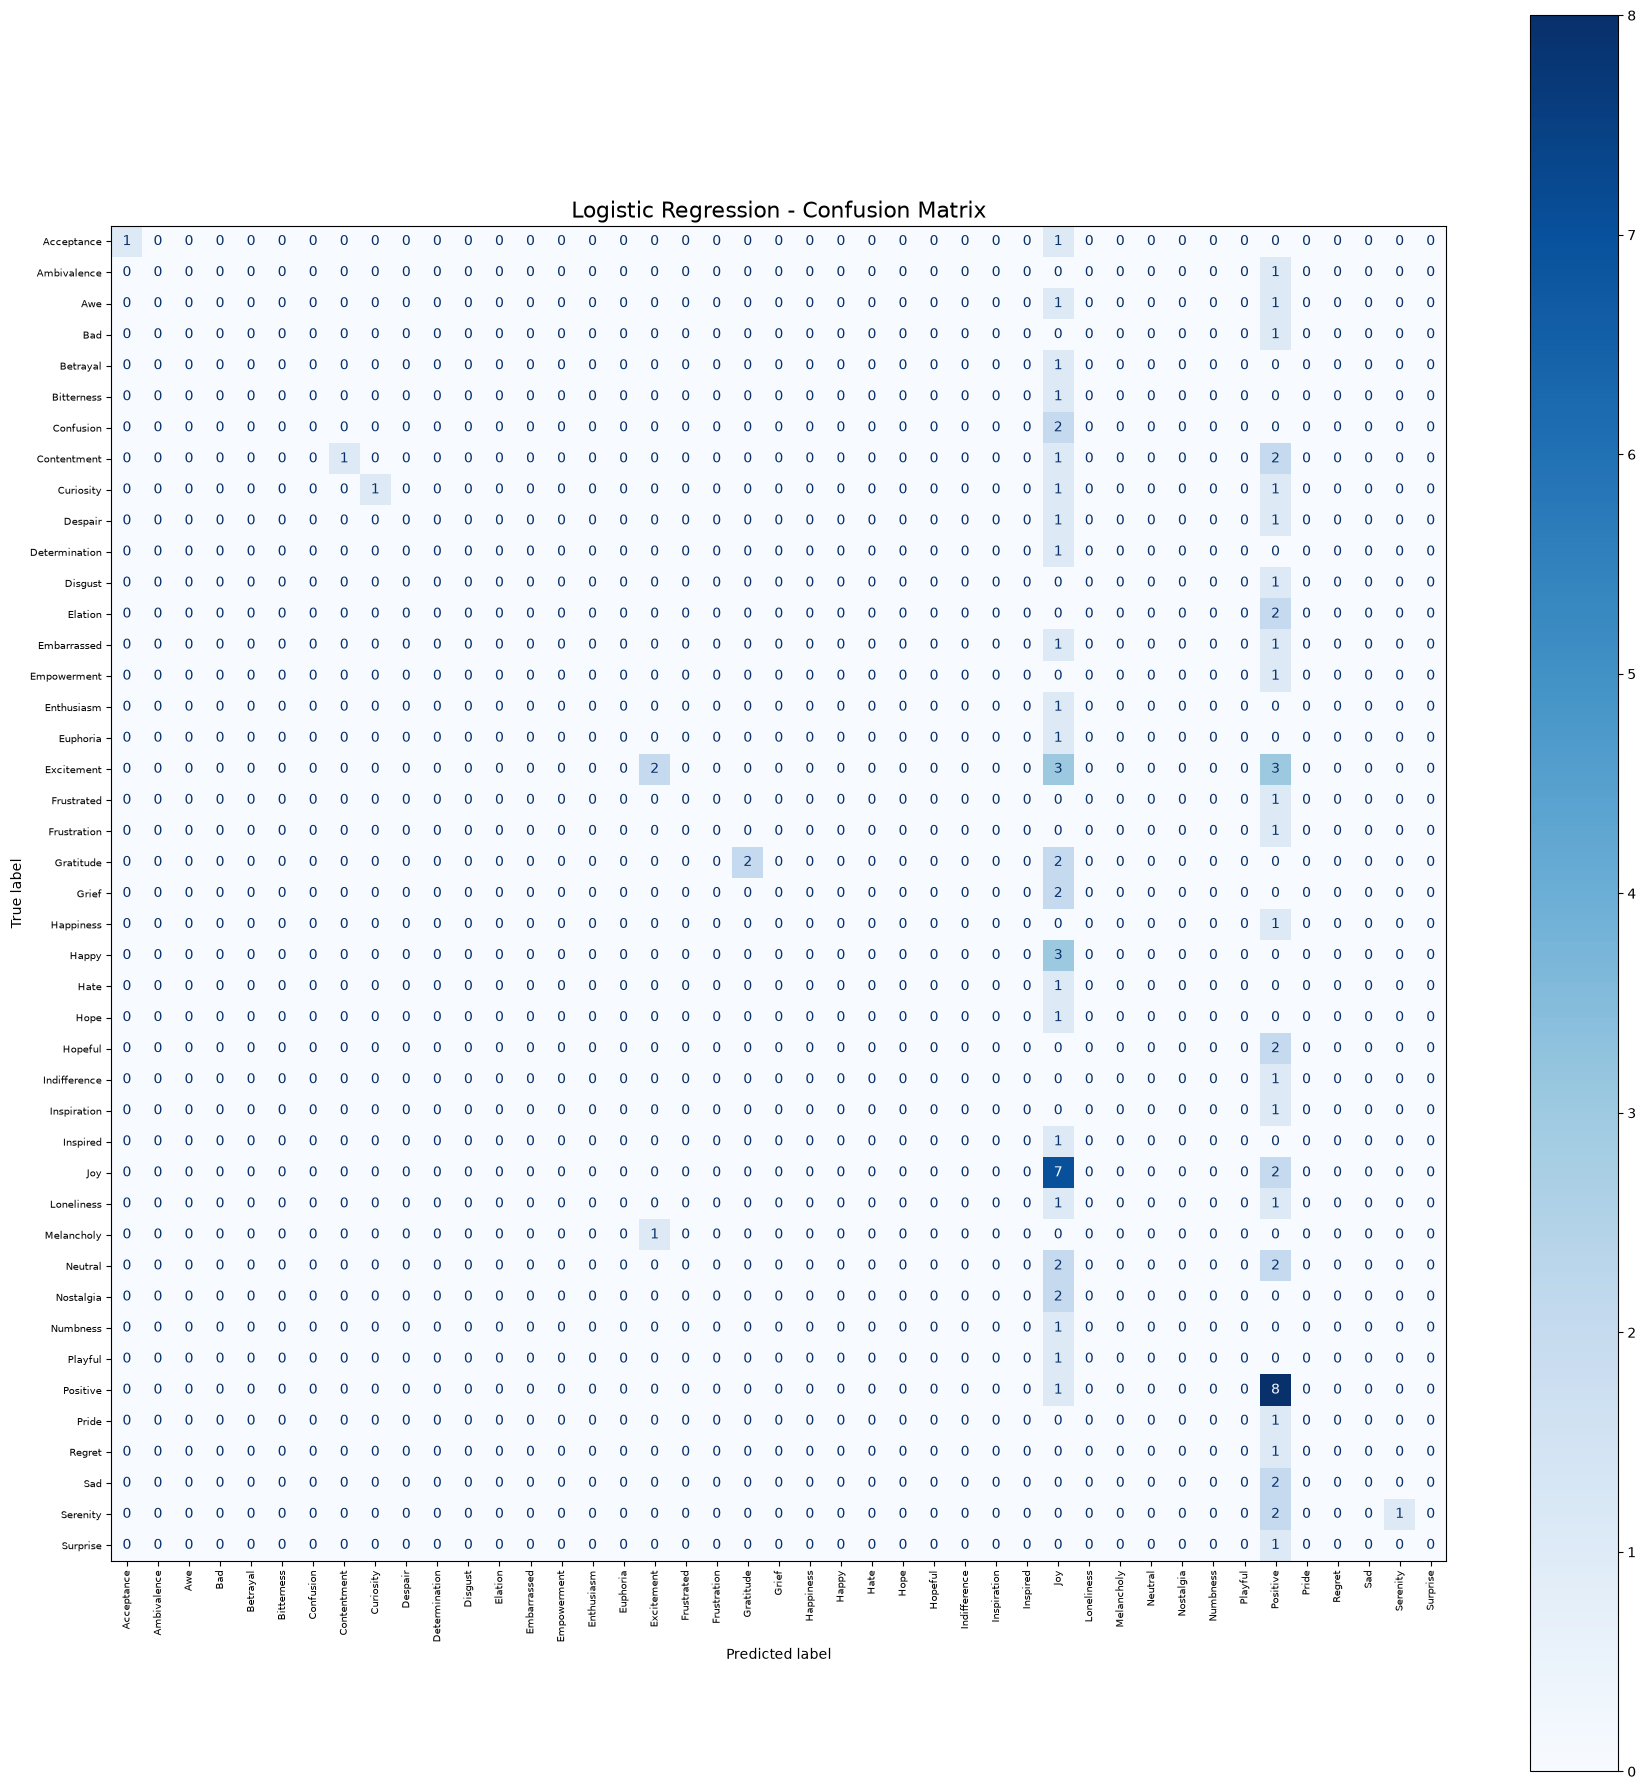

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 18))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

ax.set_title("Logistic Regression - Confusion Matrix", fontsize=16)
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.show()

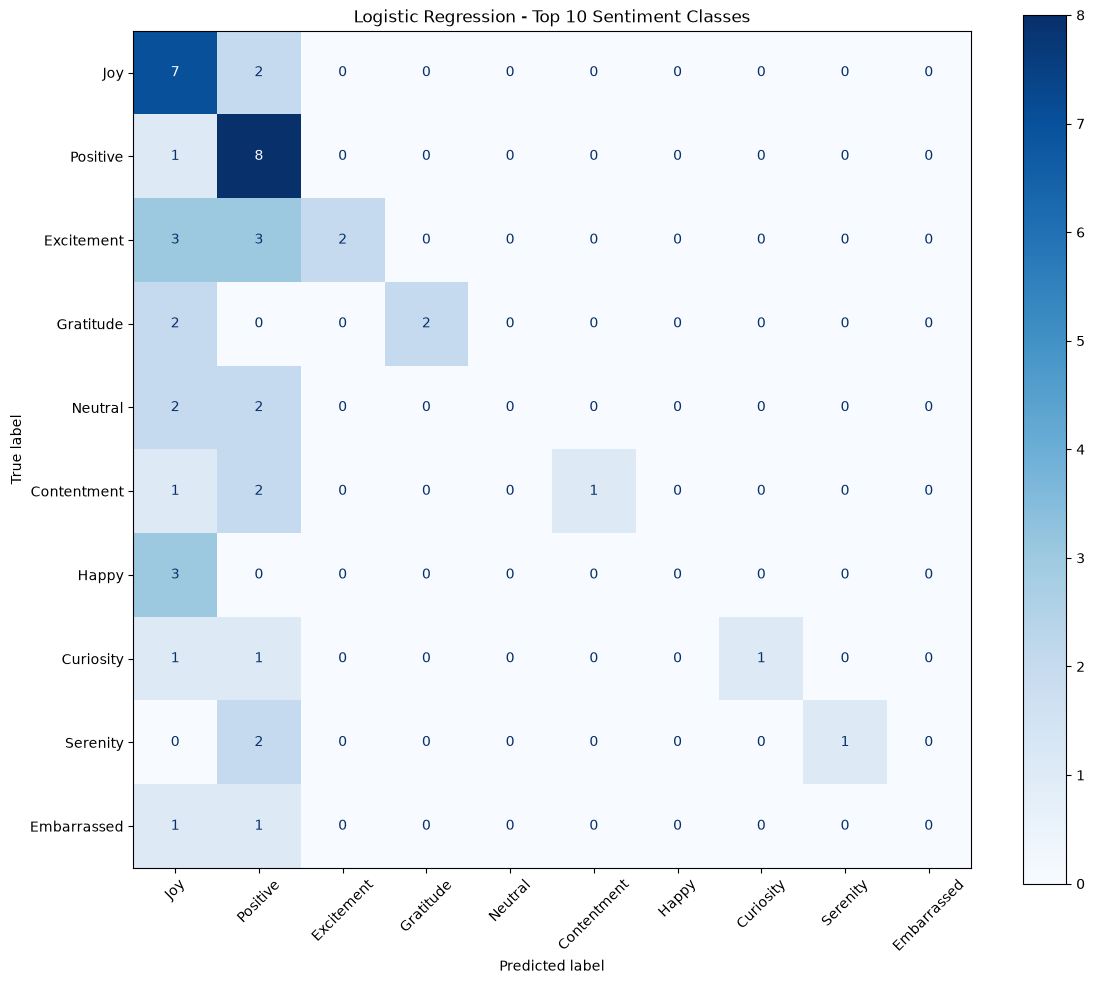

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get top 10 sentiment classes from the test data
top_classes = y_test.value_counts().head(10).index.tolist()

# Keep only test samples belonging to top 10 classes
mask = y_test.isin(top_classes)

y_test_top = y_test[mask]
y_pred_top = y_pred[mask]

# Create confusion matrix
cm = confusion_matrix(
    y_test_top,
    y_pred_top,
    labels=top_classes
)

# Display
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=top_classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=True
)

ax.set_title("Logistic Regression - Top 10 Sentiment Classes")
plt.tight_layout()
plt.show()

In [22]:
# Sample new social media texts
sample_texts = [
    "I am extremely happy today!",
    "This is the worst experience ever.",
    "I really enjoyed this amazing day.",
    "The weather is okay, nothing special."
]

# Preprocess the sample texts
clean_samples = [preprocess_text(text) for text in sample_texts]

# Convert samples using the trained TF-IDF vectorizer
sample_vectors = tfidf.transform(clean_samples)

# Predict sentiment
sample_predictions = logistic_model.predict(sample_vectors)

# Display predictions
for text, prediction in zip(sample_texts, sample_predictions):
    print("Text:", text)
    print("Predicted Sentiment:", prediction)
    print("-" * 60)

Text: I am extremely happy today!
Predicted Sentiment: Positive
------------------------------------------------------------
Text: This is the worst experience ever.
Predicted Sentiment: Positive
------------------------------------------------------------
Text: I really enjoyed this amazing day.
Predicted Sentiment: Positive
------------------------------------------------------------
Text: The weather is okay, nothing special.
Predicted Sentiment: Positive
------------------------------------------------------------


In [ ]:
## Final Insights and Conclusion
### Key Findings

- The dataset initially contained 732 records and 15 columns.
- After cleaning and filtering sentiment classes with at least 5 samples, 458 records and 43 sentiment classes were retained.
- NLP preprocessing included text cleaning, tokenization, stopword removal, and lemmatization.
- TF-IDF was used to convert cleaned text into numerical features.
- Two classification models were evaluated: Logistic Regression and Multinomial Naive Bayes.
- Logistic Regression performed better than Naive Bayes on the test dataset.
- Logistic Regression achieved an accuracy of 25% and a weighted F1-score of 18.53%.
- Naive Bayes achieved an accuracy of 18.48% and a weighted F1-score of 10.31%.
- The relatively low performance is mainly associated with the large number of sentiment classes and limited training samples per class.
- The confusion matrix shows that the model has difficulty distinguishing several sentiment categories.
- Sample predictions demonstrate that the trained model can classify new social-media text, although some negative and neutral examples were incorrectly predicted as Positive.

### Conclusion

The analysis demonstrates a complete NLP-based sentiment classification workflow, including data cleaning, text preprocessing, TF-IDF feature extraction, model training, evaluation, comparison, and prediction on unseen text.
Logistic Regression was the better-performing model among the two tested models. However, the results indicate that additional training data and better class balance would be required to improve sentiment classification performance.